#### `Import Libraries`

In [1]:
import os
import re
import hashlib
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers,Model,callbacks,optimizers,metrics
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

#### `Read Data`

In [2]:
DATASET_DIR = "Shop DataSet"

non_shop_lifters_dir = os.path.join(DATASET_DIR, "non shop lifters")
shop_lifters_dir = os.path.join(DATASET_DIR, "shop lifters")

In [3]:
def delete_all_suffix_1_files(folder_path):
    print(f"\nChecking folder: {folder_path}")

    video_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".mp4")]
    to_delete = [f for f in video_files if re.search(r"_1\.mp4$", f, re.IGNORECASE)]

    print(f"Files to delete: {len(to_delete)}")

    for f in to_delete:
        file_path = os.path.join(folder_path, f)
        try:
            os.remove(file_path)
            print(f"Deleted: {f}")
        except Exception as e:
            print(f"Error deleting {file_path}: {e}")

In [4]:
delete_all_suffix_1_files(non_shop_lifters_dir)
delete_all_suffix_1_files(shop_lifters_dir)


Checking folder: Shop DataSet\non shop lifters
Files to delete: 0

Checking folder: Shop DataSet\shop lifters
Files to delete: 0


In [5]:
def count_videos(folder_path):
    video_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".mp4")]
    return len(video_files)

non_count = count_videos(non_shop_lifters_dir)
shop_count = count_videos(shop_lifters_dir)

print("non shop lifters videos:", non_count)
print("shop lifters videos    :", shop_count)
print("Total videos           :", non_count + shop_count)

non shop lifters videos: 311
shop lifters videos    : 319
Total videos           : 630


In [6]:
CLASS_NAMES = ["non shop lifters", "shop lifters"]
CLASS_TO_LABEL = {
    "non shop lifters": 0,
    "shop lifters": 1
}

SEQ_LEN = 32
IMG_SIZE = 128
BATCH_SIZE = 4
SEED = 42

In [7]:
def collect_video_metadata(dataset_dir, class_names):
    records = []

    for cls in class_names:
        class_dir = os.path.join(dataset_dir, cls)

        if not os.path.exists(class_dir):
            print(f"Folder not found: {class_dir}")
            continue

        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)

            if not os.path.isfile(file_path):
                continue

            cap = cv2.VideoCapture(file_path)

            frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

            duration_sec = frames / fps if fps and fps > 0 else 0

            records.append({
                "class": cls,
                "label": CLASS_TO_LABEL[cls],
                "file": file_name,
                "path": file_path,
                "frames": frames,
                "fps": fps,
                "width": width,
                "height": height,
                "duration_sec": duration_sec
            })

            cap.release()

    return pd.DataFrame(records)

df = collect_video_metadata(DATASET_DIR, CLASS_NAMES)
print(df.shape)
df.head()

(630, 9)


,class,label,file,path,frames,fps,width,height,duration_sec
0,non shop lifters,0,shop_lifter_n_0.mp4,Shop DataSet\non shop lifters\shop_lifter_n_0.mp4,450,25.0,704,576,18.0
1,non shop lifters,0,shop_lifter_n_10.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,475,25.0,704,576,19.0
2,non shop lifters,0,shop_lifter_n_100.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,400,25.0,704,576,16.0
3,non shop lifters,0,shop_lifter_n_101.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,300,25.0,704,576,12.0
4,non shop lifters,0,shop_lifter_n_102.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,275,25.0,704,576,11.0


In [8]:
print(df["class"].value_counts())
print()
print(df.describe(include="all"))

class
shop lifters        319
non shop lifters    311
Name: count, dtype: int64

               class       label                file  \
count            630  630.000000                 630   
unique             2         NaN                 575   
top     shop lifters         NaN  videppppsss_40.mp4   
freq             319         NaN                   2   
mean             NaN    0.506349                 NaN   
std              NaN    0.500357                 NaN   
min              NaN    0.000000                 NaN   
25%              NaN    0.000000                 NaN   
50%              NaN    1.000000                 NaN   
75%              NaN    1.000000                 NaN   
max              NaN    1.000000                 NaN   

                                                     path       frames  \
count                                                 630   630.000000   
unique                                                630          NaN   
top     Shop DataSet\sho

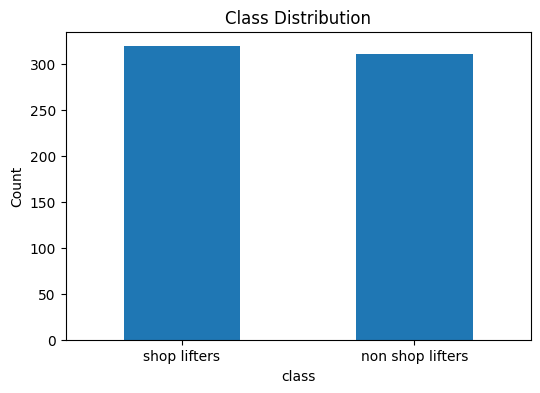

In [9]:
plt.figure(figsize=(6,4))
df["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

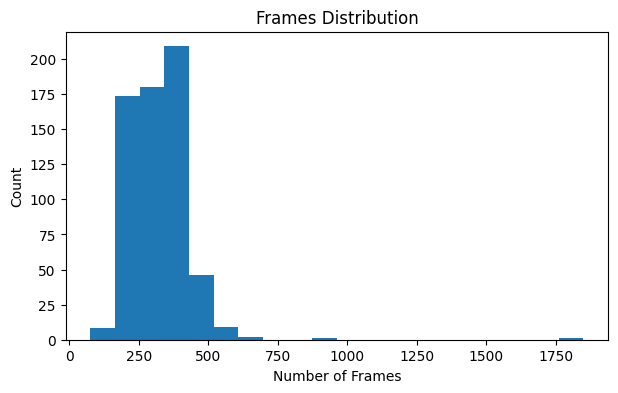

In [10]:
plt.figure(figsize=(7,4))
plt.hist(df["frames"], bins=20)
plt.title("Frames Distribution")
plt.xlabel("Number of Frames")
plt.ylabel("Count")
plt.show()

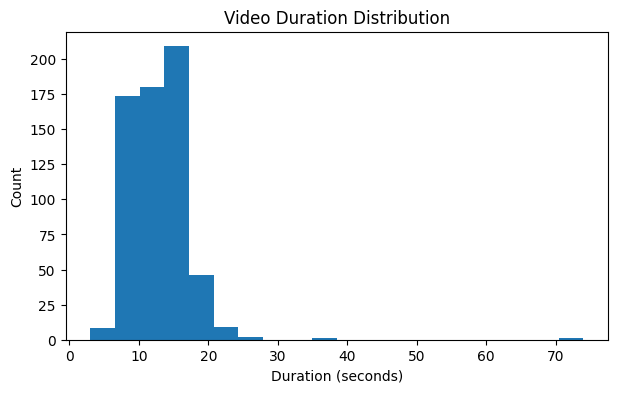

In [11]:
plt.figure(figsize=(7,4))
plt.hist(df["duration_sec"], bins=20)
plt.title("Video Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

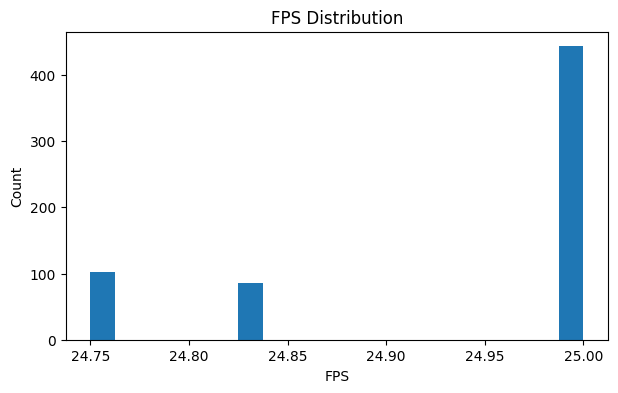

In [12]:
plt.figure(figsize=(7,4))
plt.hist(df["fps"], bins=20)
plt.title("FPS Distribution")
plt.xlabel("FPS")
plt.ylabel("Count")
plt.show()

In [13]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (441, 9)
Val  : (94, 9)
Test : (95, 9)


In [14]:
def show_sample_frames(video_path, num_frames=6):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        print("Cannot read video.")
        cap.release()
        return

    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()

    plt.figure(figsize=(15, 4))
    for i, frame in enumerate(frames):
        plt.subplot(1, len(frames), i + 1)
        plt.imshow(frame)
        plt.title(f"Frame {indices[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Shop DataSet\non shop lifters\shop_lifter_n_0.mp4


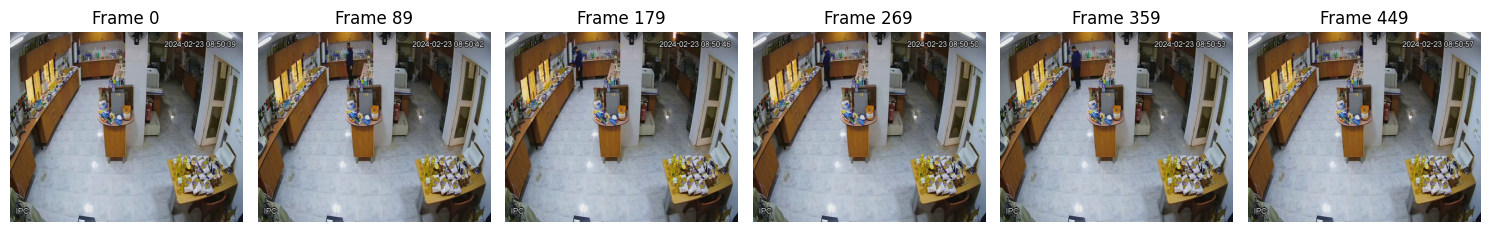

In [15]:
sample_path = df.iloc[0]["path"]
print(sample_path)
show_sample_frames(sample_path, num_frames=6)

In [16]:
def uniform_frame_sampling(video_path, seq_len=32, img_size=128):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros((seq_len, img_size, img_size, 3), dtype=np.float32)

    indices = np.linspace(0, total_frames - 1, seq_len).astype(int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if not success:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))

        frames.append(frame)

    cap.release()
    frames = np.array(frames, dtype=np.float32)
    return frames

In [17]:
def augment_video_frames(frames):
    augmented = frames.copy()

    if random.random() < 0.5:
        augmented = np.array([cv2.flip(f, 1) for f in augmented])

    if random.random() < 0.5:
        factor = random.uniform(0.8, 1.2)
        augmented = np.clip(augmented * factor, 0, 255)

    if random.random() < 0.3:
        angle = random.uniform(-10, 10)
        h, w = augmented[0].shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)

        rotated_frames = []
        for f in augmented:
            rotated = cv2.warpAffine(
                f, M, (w, h),
                borderMode=cv2.BORDER_REFLECT_101
            )
            rotated_frames.append(rotated)

        augmented = np.array(rotated_frames)

    return augmented.astype(np.float32)

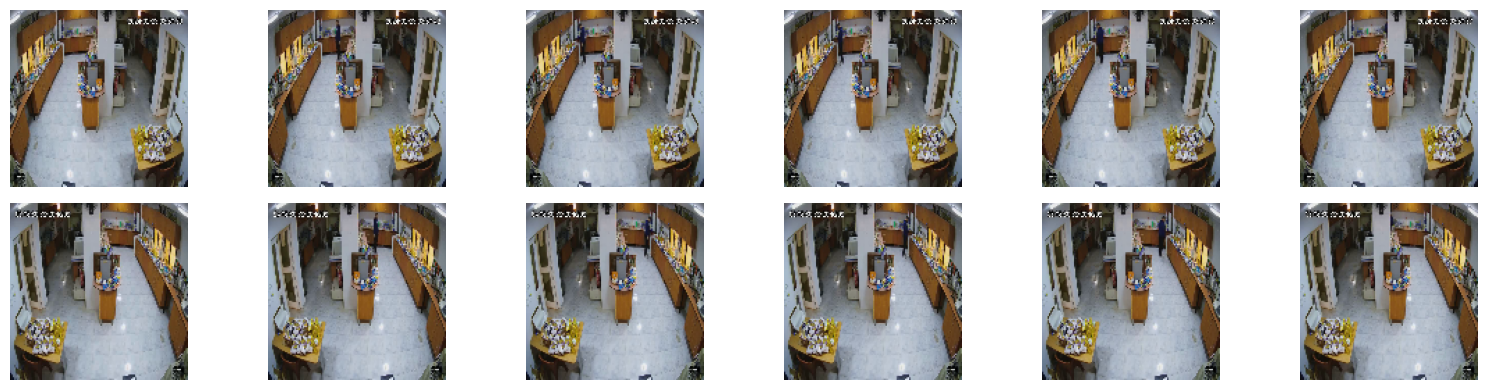

In [18]:
def show_original_vs_augmented(video_path, seq_len=32, img_size=128):
    original = uniform_frame_sampling(video_path, seq_len=seq_len, img_size=img_size)
    augmented = augment_video_frames(original)

    plt.figure(figsize=(16, 4))
    for i in range(seq_len):
        plt.subplot(2, seq_len, i + 1)
        plt.imshow(original[i].astype(np.uint8))
        plt.axis("off")
        if i == 0:
            plt.ylabel("Original", fontsize=12)

        plt.subplot(2, seq_len, seq_len + i + 1)
        plt.imshow(augmented[i].astype(np.uint8))
        plt.axis("off")
        if i == 0:
            plt.ylabel("Augmented", fontsize=12)

    plt.tight_layout()
    plt.show()

show_original_vs_augmented(sample_path, seq_len=6, img_size=IMG_SIZE)

In [19]:
def preprocess_video(video_path, seq_len=32, img_size=128, augment=False):
    frames = uniform_frame_sampling(video_path, seq_len=seq_len, img_size=img_size)

    if augment:
        frames = augment_video_frames(frames)

    frames = frames.astype(np.float32)
    frames = preprocess_input(frames) 

    return frames

In [20]:
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=4, seq_len=32, img_size=128, augment=False, shuffle=True):
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        X_batch = []
        y_batch = []

        for _, row in batch_df.iterrows():
            video = preprocess_video(
                row["path"],
                seq_len=self.seq_len,
                img_size=self.img_size,
                augment=self.augment
            )
            X_batch.append(video)
            y_batch.append(row["label"])

        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = np.array(y_batch, dtype=np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [21]:
train_gen = VideoDataGenerator(
    train_df,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    augment=True,
    shuffle=True
)

val_gen = VideoDataGenerator(
    val_df,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

test_gen = VideoDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

print("Train steps:", len(train_gen))
print("Val steps  :", len(val_gen))
print("Test steps :", len(test_gen))

Train steps: 111
Val steps  : 24
Test steps : 24


In [22]:
X_batch, y_batch = train_gen[0]
print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)
print("range:", X_batch.min(), X_batch.max())

X_batch: (4, 32, 128, 128, 3)
y_batch: (4,)
range: -1.0 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


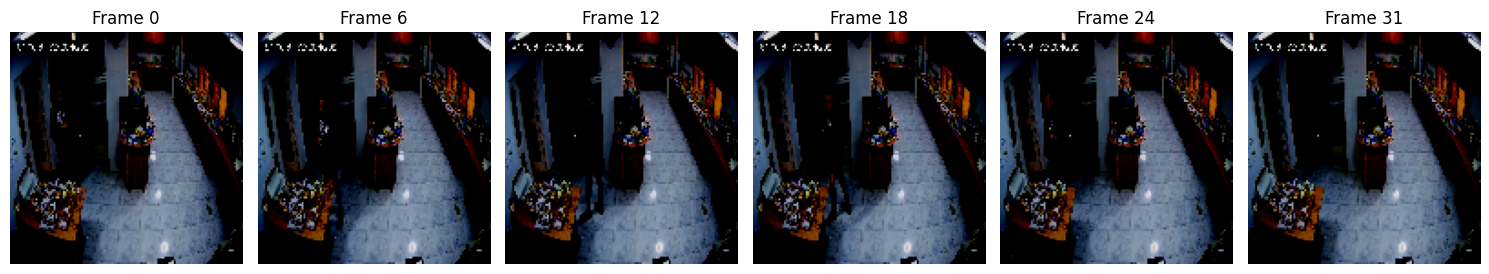

Label: 1.0


In [23]:
def show_preprocessed_video(video_tensor, num_frames=6):
    indices = np.linspace(0, len(video_tensor) - 1, num_frames).astype(int)

    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(video_tensor[idx])
        plt.title(f"Frame {idx}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_preprocessed_video(X_batch[0], num_frames=6)
print("Label:", y_batch[0])

In [24]:
def build_mobilenetv2_convlstm_model(seq_len=32, img_size=128, train_backbone=False):
    video_input = layers.Input(shape=(seq_len, img_size, img_size, 3), name="video_input")

    backbone = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    backbone.trainable = train_backbone

    x = layers.TimeDistributed(backbone, name="td_mobilenetv2")(video_input)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D(), name="td_gap")(x)

    x = layers.Reshape((seq_len, 1, 1, 1280), name="reshape_for_convlstm")(x)

    x = layers.ConvLSTM2D(
        filters=128,
        kernel_size=(1, 1),
        padding="same",
        return_sequences=True,
        activation="tanh",
        name="convlstm_1"
    )(x)
    x = layers.BatchNormalization(name="bn_1")(x)

    x = layers.ConvLSTM2D(
        filters=64,
        kernel_size=(1, 1),
        padding="same",
        return_sequences=False,
        activation="tanh",
        name="convlstm_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.5, name="dropout_1")(x)
    x = layers.Dense(64, activation="relu", name="dense_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)

    output = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(video_input, output, name="MobileNetV2_ConvLSTM")
    return model

model = build_mobilenetv2_convlstm_model(
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    train_backbone=False
)

model.summary()

Model: "MobileNetV2_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 32, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_mobilenetv2                  │ (None, 32, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_gap (TimeDistributed)        │ (None, 32, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_for_convlstm (Reshape)  │ (None, 32, 1, 1, 1280) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_1 (ConvLSTM2D)         │ (None, 32, 1, 1, 128)  │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 1, 1, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_2 (ConvLSTM2D)         │ (None, 1, 1, 64)       │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 1, 1, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,209 (11.62 MB)

 Trainable params: 787,841 (3.01 MB)

 Non-trainable params: 2,258,368 (8.61 MB)

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [26]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    "best_mobilenetv2_convlstm.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_callback]
)

c:\Users\moham\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5284 - auc: 0.5492 - loss: 0.7648 - precision: 0.5323 - recall: 0.5840
Epoch 1: val_accuracy improved from None to 0.57447, saving model to best_mobilenetv2_convlstm.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 580s 4s/step - accuracy: 0.5646 - auc: 0.5784 - loss: 0.7404 - precision: 0.5677 - recall: 0.5830 - val_accuracy: 0.5745 - val_auc: 0.8503 - val_loss: 0.6619 - val_precision: 0.5455 - val_recall: 1.0000
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5880 - auc: 0.6287 - loss: 0.7005 - precision: 0.5900 - recall: 0.5719
Epoch 2: val_accuracy improved from 0.57447 to 0.82979, saving model to best_mobilenetv2_convlstm.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 484s 4s/step - accuracy: 0.6145 - auc: 0.6378 - loss: 0.6952 - precision: 0.6199 - recall: 0.6143 - val_accuracy: 0.8298 - val_auc: 0.9447 - val_loss: 0.5460 - val_precision: 0.7581 - val_recall: 0.9792
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accura

In [27]:
backbone = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.TimeDistributed):
        if isinstance(layer.layer, tf.keras.Model):
            backbone = layer.layer
            break

if backbone is not None:
    backbone.trainable = True

    for l in backbone.layers[:-30]:
        l.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[checkpoint_callback]
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7526 - auc: 0.8116 - loss: 0.5534 - precision: 0.7719 - recall: 0.7076
Epoch 1: val_accuracy did not improve from 0.97872
111/111 ━━━━━━━━━━━━━━━━━━━━ 755s 5s/step - accuracy: 0.7415 - auc: 0.8039 - loss: 0.5663 - precision: 0.7583 - recall: 0.7175 - val_accuracy: 0.9149 - val_auc: 0.9798 - val_loss: 0.2003 - val_precision: 0.8846 - val_recall: 0.9583
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7892 - auc: 0.8475 - loss: 0.5003 - precision: 0.7620 - recall: 0.8194
Epoch 2: val_accuracy did not improve from 0.97872
111/111 ━━━━━━━━━━━━━━━━━━━━ 585s 5s/step - accuracy: 0.7823 - auc: 0.8450 - loss: 0.5060 - precision: 0.7873 - recall: 0.7803 - val_accuracy: 0.9574 - val_auc: 0.9928 - val_loss: 0.1454 - val_precision: 0.9400 - val_recall: 0.9792
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8159 - auc: 0.8971 - loss: 0.4061 - precision: 0.8266 - recall: 0.8114
Epoch 3: val_accuracy did 

In [28]:
model.save('mobilenetv2_convlstm.keras')

In [29]:
best_model = load_model('mobilenetv2_convlstm.keras')

test_results = best_model.evaluate(test_gen)

loss, accuracy, precision, recall, auc = test_results

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test AUC: {auc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9368 - auc: 0.9936 - loss: 0.1168 - precision: 0.9038 - recall: 0.9792
Test Loss: 0.1168
Test Accuracy: 0.9368
Test Precision: 0.9038
Test Recall: 0.9792
Test AUC: 0.9936


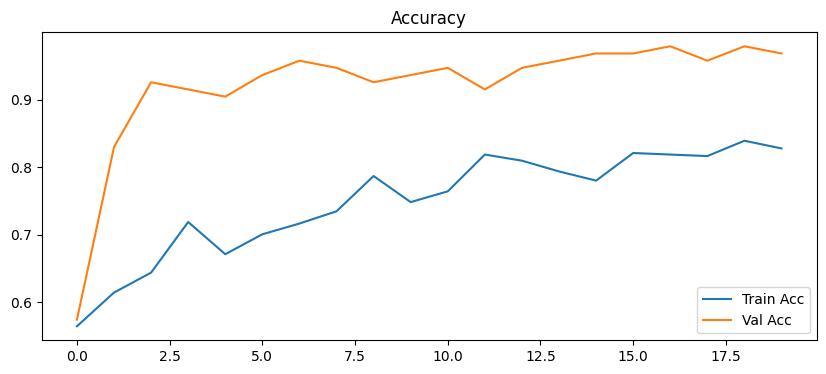

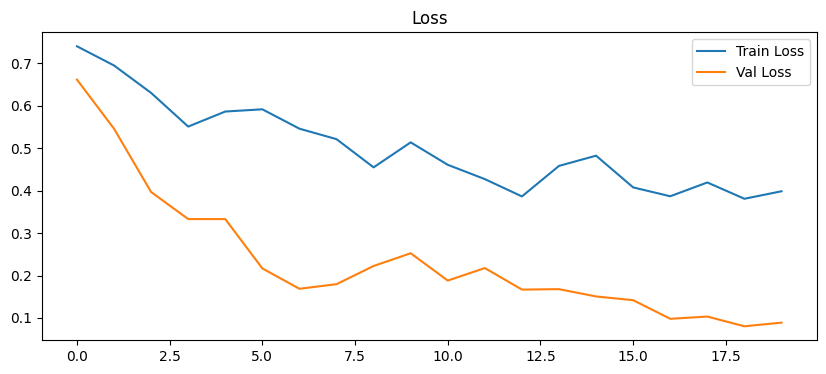

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()
plt.show()

In [31]:
y_pred_prob = model.predict(test_gen, verbose=1).flatten()
y_pred = (y_pred_prob > 0.5).astype(np.int32)

y_true = test_df["label"].values[:len(y_pred)]

print(classification_report(
    y_true,
    y_pred,
    target_names=["non shop lifters", "shop lifters"]
))

24/24 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step
                  precision    recall  f1-score   support

non shop lifters       0.98      0.89      0.93        47
    shop lifters       0.90      0.98      0.94        48

        accuracy                           0.94        95
       macro avg       0.94      0.94      0.94        95
    weighted avg       0.94      0.94      0.94        95



[[42  5]
 [ 1 47]]


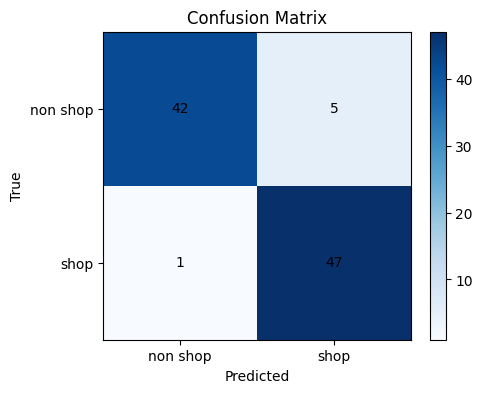

In [32]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["non shop", "shop"])
plt.yticks([0,1], ["non shop", "shop"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [33]:
def predict_single_video(model, video_path, seq_len=32, img_size=128):
    video = preprocess_video(video_path, seq_len=seq_len, img_size=img_size, augment=False)
    x = np.expand_dims(video, axis=0)
    prob = model.predict(x, verbose=0)[0][0]
    label = 1 if prob > 0.5 else 0
    class_name = "shop lifters" if label == 1 else "non shop lifters"
    return prob, label, class_name

sample_video = test_df.iloc[0]["path"]
prob, label, class_name = predict_single_video(model, sample_video, seq_len=SEQ_LEN, img_size=IMG_SIZE)

print("Video:", sample_video)
print("Probability:", prob)
print("Predicted label:", label)
print("Predicted class:", class_name)

Video: Shop DataSet\shop lifters\shop_lifter_88.mp4
Probability: 0.88501745
Predicted label: 1
Predicted class: shop lifters


In [34]:
def predict_single_video(model, video_path, seq_len=32, img_size=128):
    video = preprocess_video(video_path, seq_len=seq_len, img_size=img_size, augment=False)
    x = np.expand_dims(video, axis=0)
    prob = model.predict(x, verbose=0)[0][0]
    label = 1 if prob > 0.5 else 0
    class_name = "shop lifters" if label == 1 else "non shop lifters"
    return prob, label, class_name

sample_video = test_df.iloc[5]["path"]
prob, label, class_name = predict_single_video(model, sample_video, seq_len=SEQ_LEN, img_size=IMG_SIZE)

print("Video:", sample_video)
print("Probability:", prob)
print("Predicted label:", label)
print("Predicted class:", class_name)

Video: Shop DataSet\non shop lifters\shop_lifter_n_2.mp4
Probability: 0.009242033
Predicted label: 0
Predicted class: non shop lifters
